### CycleGAN
Author: A_K_Nain

Taken from: https://keras.io/examples/generative/cyclegan/

Description: Implementation of CycleGAN.



### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# import tensorflow_addons as tfa
import tensorflow_datasets as tfds

tfds.disable_progress_bar()
autotune = tf.data.AUTOTUNE
tfa = tf.keras


I0000 00:00:1773606141.671373    1758 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Prepare the dataset
In this example, we will be using the horse to zebra dataset.

In [2]:
# Load the horse-zebra dataset using tensorflow-datasets.
dataset, _ = tfds.load("cycle_gan/horse2zebra", with_info=True, as_supervised=True)
train_horses, train_zebras = dataset["trainA"], dataset["trainB"]
test_horses, test_zebras = dataset["testA"], dataset["testB"]

# Define the standard image size.
orig_img_size = (286, 286)
# Size of the random crops to be used during training.
input_img_size = (256, 256, 3)
# Weights initializer for the layers.
kernel_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
# Gamma initializer for instance normalization.
gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

buffer_size = 256
batch_size = 1


def normalize_img(img):
    img = tf.cast(img, dtype=tf.float32)
    # Map values in the range [-1, 1]
    return (img / 127.5) - 1.0


def preprocess_train_image(img, label):
    # Random flip
    img = tf.image.random_flip_left_right(img)
    # Resize to the original size first
    img = tf.image.resize(img, [*orig_img_size])
    # Random crop to 256X256
    img = tf.image.random_crop(img, size=[*input_img_size])
    # Normalize the pixel values in the range [-1, 1]
    img = normalize_img(img)
    return img


def preprocess_test_image(img, label):
    # Only resizing and normalization for the test images.
    img = tf.image.resize(img, [input_img_size[0], input_img_size[1]])
    img = normalize_img(img)
    return img

I0000 00:00:1773606145.656405    1758 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43629 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:34:00.0, compute capability: 8.9


### Create Dataset objects

In [3]:
# Apply the preprocessing operations to the training data
train_horses = (
    train_horses.map(preprocess_train_image, num_parallel_calls=autotune)
    .cache()
    .shuffle(buffer_size)
    .batch(batch_size)
)
train_zebras = (
    train_zebras.map(preprocess_train_image, num_parallel_calls=autotune)
    .cache()
    .shuffle(buffer_size)
    .batch(batch_size)
)

# Apply the preprocessing operations to the test data
test_horses = (
    test_horses.map(preprocess_test_image, num_parallel_calls=autotune)
    .cache()
    .shuffle(buffer_size)
    .batch(batch_size)
)
test_zebras = (
    test_zebras.map(preprocess_test_image, num_parallel_calls=autotune)
    .cache()
    .shuffle(buffer_size)
    .batch(batch_size)
)

### Visualize some samples

I0000 00:00:1773606146.705334    2500 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1773606146.893767    2523 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773606146.893892    2595 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773606146.89

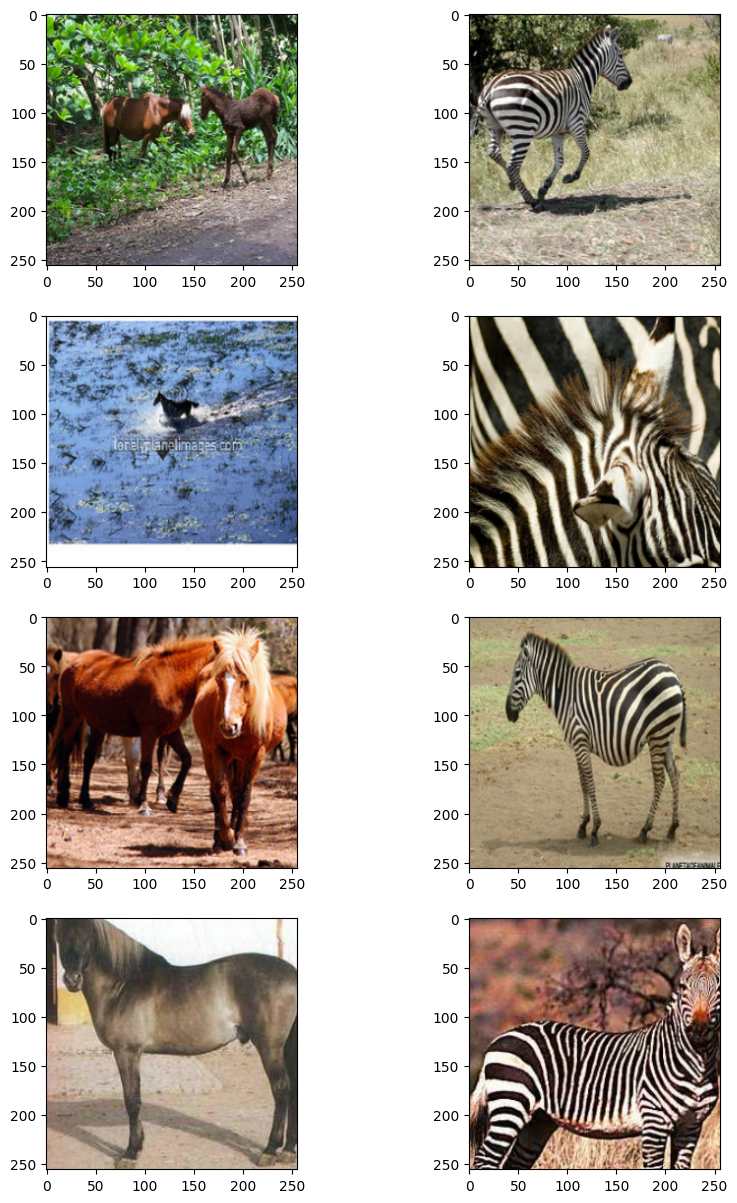

In [4]:
_, ax = plt.subplots(4, 2, figsize=(10, 15))
for i, samples in enumerate(zip(train_horses.take(4), train_zebras.take(4))):
    horse = (((samples[0][0] * 127.5) + 127.5).numpy()).astype(np.uint8)
    zebra = (((samples[1][0] * 127.5) + 127.5).numpy()).astype(np.uint8)
    ax[i, 0].imshow(horse)
    ax[i, 1].imshow(zebra)
plt.show()

### Building blocks used in the CycleGAN generators and discriminators

In [5]:
class ReflectionPadding2D(layers.Layer):
    """Implements Reflection Padding as a layer.

    Args:
        padding(tuple): Amount of padding for the
        spatial dimensions.

    Returns:
        A padded tensor with the same type as the input tensor.
    """

    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        super().__init__(**kwargs)

    def call(self, input_tensor, mask=None):
        padding_width, padding_height = self.padding
        padding_tensor = [
            [0, 0],
            [padding_height, padding_height],
            [padding_width, padding_width],
            [0, 0],
        ]
        return tf.pad(input_tensor, padding_tensor, mode="REFLECT")


def residual_block(
    x,
    activation,
    kernel_initializer=kernel_init,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="valid",
    gamma_initializer=gamma_init,
    use_bias=False,
):
    dim = x.shape[-1]
    input_tensor = x

    x = ReflectionPadding2D()(input_tensor)
    x = layers.Conv2D(
        dim,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(     groups=-1,     gamma_initializer=gamma_initializer )(x)
    x = activation(x)

    x = ReflectionPadding2D()(x)
    x = layers.Conv2D(
        dim,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(     groups=-1,     gamma_initializer=gamma_initializer )(x)
    x = layers.add([input_tensor, x])
    return x


def downsample(
    x,
    filters,
    activation,
    kernel_initializer=kernel_init,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    gamma_initializer=gamma_init,
    use_bias=False,
):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(
    groups=-1,
    gamma_initializer=gamma_initializer
)(x)
    if activation:
        x = activation(x)
    return x


def upsample(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    kernel_initializer=kernel_init,
    gamma_initializer=gamma_init,
    use_bias=False,
):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size,
        strides=strides,
        padding=padding,
        kernel_initializer=kernel_initializer,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(     groups=-1,     gamma_initializer=gamma_initializer )(x)
    if activation:
        x = activation(x)
    return x

### Build the generators
The generator consists of downsampling blocks: nine residual blocks and upsampling blocks. The structure of the generator is the following:

``` 
c7s1-64 ==> Conv block with 'relu' activation, filter size of 7
d128 ====|
         |-> 2 downsampling blocks
d256 ====|
R256 ====|
R256     |
R256     |
R256     |
R256     |-> 9 residual blocks
R256     |
R256     |
R256     |
R256 ====|
u128 ====|
         |-> 2 upsampling blocks
u64  ====|
c7s1-3 => Last conv block with 'tanh' activation, filter size of 7.


In [6]:
def get_resnet_generator(
    filters=64,
    num_downsampling_blocks=2,
    num_residual_blocks=9,
    num_upsample_blocks=2,
    gamma_initializer=gamma_init,
    name=None,
):
    img_input = layers.Input(shape=input_img_size, name=name + "_img_input")
    x = ReflectionPadding2D(padding=(3, 3))(img_input)
    x = layers.Conv2D(filters, (7, 7), kernel_initializer=kernel_init, use_bias=False)(
        x
    )
    x = keras.layers.GroupNormalization(     groups=-1,     gamma_initializer=gamma_initializer )(x)
    x = layers.Activation("relu")(x)

    # Downsampling
    for _ in range(num_downsampling_blocks):
        filters *= 2
        x = downsample(x, filters=filters, activation=layers.Activation("relu"))

    # Residual blocks
    for _ in range(num_residual_blocks):
        x = residual_block(x, activation=layers.Activation("relu"))

    # Upsampling
    for _ in range(num_upsample_blocks):
        filters //= 2
        x = upsample(x, filters, activation=layers.Activation("relu"))

    # Final block
    x = ReflectionPadding2D(padding=(3, 3))(x)
    x = layers.Conv2D(3, (7, 7), padding="valid")(x)
    x = layers.Activation("tanh")(x)

    model = keras.models.Model(img_input, x, name=name)
    return model

### Build the discriminators
The discriminators implement the following architecture: C64->C128->C256->C512

In [7]:
def get_discriminator(
    filters=64, kernel_initializer=kernel_init, num_downsampling=3, name=None
):
    img_input = layers.Input(shape=input_img_size, name=name + "_img_input")
    x = layers.Conv2D(
        filters,
        (4, 4),
        strides=(2, 2),
        padding="same",
        kernel_initializer=kernel_initializer,
    )(img_input)
    x = layers.LeakyReLU(0.2)(x)

    num_filters = filters
    for num_downsample_block in range(3):
        num_filters *= 2
        if num_downsample_block < 2:
            x = downsample(
                x,
                filters=num_filters,
                activation=layers.LeakyReLU(0.2),
                kernel_size=(4, 4),
                strides=(2, 2),
            )
        else:
            x = downsample(
                x,
                filters=num_filters,
                activation=layers.LeakyReLU(0.2),
                kernel_size=(4, 4),
                strides=(1, 1),
            )

    x = layers.Conv2D(
        1, (4, 4), strides=(1, 1), padding="same", kernel_initializer=kernel_initializer
    )(x)

    model = keras.models.Model(inputs=img_input, outputs=x, name=name)
    return model


# Get the generators
gen_G = get_resnet_generator(name="generator_G")
gen_F = get_resnet_generator(name="generator_F")

# Get the discriminators
disc_X = get_discriminator(name="discriminator_X")
disc_Y = get_discriminator(name="discriminator_Y")

### Build the CycleGAN model
We will override the train_step() method of the Model class for training via fit().

In [8]:
class CycleGan(keras.Model):
    def __init__(
        self,
        generator_G,
        generator_F,
        discriminator_X,
        discriminator_Y,
        lambda_cycle=10.0,
        lambda_identity=0.5,
    ):
        super().__init__()
        self.gen_G = generator_G
        self.gen_F = generator_F
        self.disc_X = discriminator_X
        self.disc_Y = discriminator_Y
        self.lambda_cycle = lambda_cycle
        self.lambda_identity = lambda_identity

    def compile(
        self,
        gen_G_optimizer,
        gen_F_optimizer,
        disc_X_optimizer,
        disc_Y_optimizer,
        gen_loss_fn,
        disc_loss_fn,
    ):
        super().compile()
        self.gen_G_optimizer = gen_G_optimizer
        self.gen_F_optimizer = gen_F_optimizer
        self.disc_X_optimizer = disc_X_optimizer
        self.disc_Y_optimizer = disc_Y_optimizer
        self.generator_loss_fn = gen_loss_fn
        self.discriminator_loss_fn = disc_loss_fn
        self.cycle_loss_fn = keras.losses.MeanAbsoluteError()
        self.identity_loss_fn = keras.losses.MeanAbsoluteError()

        # Loss metrics
        self.g_adv_loss_metric = keras.metrics.Mean(name="g_adv_loss")
        self.f_adv_loss_metric = keras.metrics.Mean(name="f_adv_loss")

        self.cycle_loss_metric = keras.metrics.Mean(name="cycle_loss")
        self.identity_loss_metric = keras.metrics.Mean(name="identity_loss")

        self.d_x_loss_metric = keras.metrics.Mean(name="d_x_loss")
        self.d_y_loss_metric = keras.metrics.Mean(name="d_y_loss")

        self.g_total_loss_metric = keras.metrics.Mean(name="g_total_loss")
        self.f_total_loss_metric = keras.metrics.Mean(name="f_total_loss")
    
    @property
    def metrics(self):
        return [
            self.g_adv_loss_metric,
            self.f_adv_loss_metric,
            self.cycle_loss_metric,
            self.identity_loss_metric,
            self.d_x_loss_metric,
            self.d_y_loss_metric,
            self.g_total_loss_metric,
            self.f_total_loss_metric,
        ]

    def train_step(self, batch_data):
        # x is Horse and y is zebra
        real_x, real_y = batch_data

        # For CycleGAN, we need to calculate different
        # kinds of losses for the generators and discriminators.
        # We will perform the following steps here:
        #
        # 1. Pass real images through the generators and get the generated images
        # 2. Pass the generated images back to the generators to check if we
        #    can predict the original image from the generated image.
        # 3. Do an identity mapping of the real images using the generators.
        # 4. Pass the generated images in 1) to the corresponding discriminators.
        # 5. Calculate the generators total loss (adversarial + cycle + identity)
        # 6. Calculate the discriminators loss
        # 7. Update the weights of the generators
        # 8. Update the weights of the discriminators
        # 9. Return the losses in a dictionary

        with tf.GradientTape(persistent=True) as tape:
            # Horse to fake zebra
            fake_y = self.gen_G(real_x, training=True)
            # Zebra to fake horse -> y2x
            fake_x = self.gen_F(real_y, training=True)

            # Cycle (Horse to fake zebra to fake horse): x -> y -> x
            cycled_x = self.gen_F(fake_y, training=True)
            # Cycle (Zebra to fake horse to fake zebra) y -> x -> y
            cycled_y = self.gen_G(fake_x, training=True)

            # Identity mapping
            same_x = self.gen_F(real_x, training=True)
            same_y = self.gen_G(real_y, training=True)

            # Discriminator output
            disc_real_x = self.disc_X(real_x, training=True)
            disc_fake_x = self.disc_X(fake_x, training=True)

            disc_real_y = self.disc_Y(real_y, training=True)
            disc_fake_y = self.disc_Y(fake_y, training=True)

            # Generator adversarial loss
            gen_G_loss = self.generator_loss_fn(disc_fake_y)
            gen_F_loss = self.generator_loss_fn(disc_fake_x)

            # Generator cycle loss
            cycle_loss_G = self.cycle_loss_fn(real_y, cycled_y) * self.lambda_cycle
            cycle_loss_F = self.cycle_loss_fn(real_x, cycled_x) * self.lambda_cycle

            # Generator identity loss
            id_loss_G = (
                self.identity_loss_fn(real_y, same_y)
                * self.lambda_cycle
                * self.lambda_identity
            )
            id_loss_F = (
                self.identity_loss_fn(real_x, same_x)
                * self.lambda_cycle
                * self.lambda_identity
            )

            # Total generator loss
            total_loss_G = gen_G_loss + cycle_loss_G + id_loss_G
            total_loss_F = gen_F_loss + cycle_loss_F + id_loss_F

            # Discriminator loss
            disc_X_loss = self.discriminator_loss_fn(disc_real_x, disc_fake_x)
            disc_Y_loss = self.discriminator_loss_fn(disc_real_y, disc_fake_y)

        # Get the gradients for the generators
        grads_G = tape.gradient(total_loss_G, self.gen_G.trainable_variables)
        grads_F = tape.gradient(total_loss_F, self.gen_F.trainable_variables)

        # Get the gradients for the discriminators
        disc_X_grads = tape.gradient(disc_X_loss, self.disc_X.trainable_variables)
        disc_Y_grads = tape.gradient(disc_Y_loss, self.disc_Y.trainable_variables)

        # Update the weights of the generators
        self.gen_G_optimizer.apply_gradients(
            zip(grads_G, self.gen_G.trainable_variables)
        )
        self.gen_F_optimizer.apply_gradients(
            zip(grads_F, self.gen_F.trainable_variables)
        )

        # Update the weights of the discriminators
        self.disc_X_optimizer.apply_gradients(
            zip(disc_X_grads, self.disc_X.trainable_variables)
        )
        self.disc_Y_optimizer.apply_gradients(
            zip(disc_Y_grads, self.disc_Y.trainable_variables)
        )

        # Update loss metrics
        self.g_adv_loss_metric.update_state(gen_G_loss)
        self.f_adv_loss_metric.update_state(gen_F_loss)

        self.cycle_loss_metric.update_state(cycle_loss_G + cycle_loss_F)
        self.identity_loss_metric.update_state(id_loss_G + id_loss_F)

        self.d_x_loss_metric.update_state(disc_X_loss)
        self.d_y_loss_metric.update_state(disc_Y_loss)

        self.g_total_loss_metric.update_state(total_loss_G)
        self.f_total_loss_metric.update_state(total_loss_F)

        return {
            "g_adv_loss": self.g_adv_loss_metric.result(),
            "f_adv_loss": self.f_adv_loss_metric.result(),
            "cycle_loss": self.cycle_loss_metric.result(),
            "identity_loss": self.identity_loss_metric.result(),
            "d_x_loss": self.d_x_loss_metric.result(),
            "d_y_loss": self.d_y_loss_metric.result(),
            "g_total_loss": self.g_total_loss_metric.result(),
            "f_total_loss": self.f_total_loss_metric.result(),
        }


### Create a callback that periodically saves generated images

In [9]:
class GANMonitor(keras.callbacks.Callback):
    """A callback to generate and save images after each epoch"""

    def __init__(self, num_img=4):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        _, ax = plt.subplots(4, 2, figsize=(10, 8))
        for i, img in enumerate(test_horses.take(self.num_img)):
            prediction = self.model.gen_G(img)[0].numpy()
            prediction = (prediction * 127.5 + 127.5).astype(np.uint8)
            img = (img[0] * 127.5 + 127.5).numpy().astype(np.uint8)

            ax[i, 0].imshow(img)
            ax[i, 1].imshow(prediction)
            ax[i, 0].set_title("Input image")
            ax[i, 1].set_title("Translated image")
            ax[i, 0].axis("off")
            ax[i, 1].axis("off")

            prediction = keras.utils.array_to_img(prediction)
            prediction.save(
                "generated/cyclegan/{i}_{epoch}.png".format(i=i, epoch=epoch + 1)
            )
        plt.show()
        plt.close()


### Train the end-to-end model


In [10]:
# Loss function for evaluating adversarial loss
adv_loss_fn = keras.losses.MeanSquaredError()

# Define the loss function for the generators
def generator_loss_fn(fake):
    fake_loss = adv_loss_fn(tf.ones_like(fake), fake)
    return fake_loss


# Define the loss function for the discriminators
def discriminator_loss_fn(real, fake):
    real_loss = adv_loss_fn(tf.ones_like(real), real)
    fake_loss = adv_loss_fn(tf.zeros_like(fake), fake)
    return (real_loss + fake_loss) * 0.5


# Create cycle gan model
cycle_gan_model = CycleGan(
    generator_G=gen_G, generator_F=gen_F, discriminator_X=disc_X, discriminator_Y=disc_Y
)

# Compile the model
cycle_gan_model.compile(
    gen_G_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_F_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_X_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_Y_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_loss_fn=generator_loss_fn,
    disc_loss_fn=discriminator_loss_fn,
)

cycle_gan_model.build(input_shape=[(None, 256, 256, 3), (None, 256, 256, 3)])

# Callbacks
plotter = GANMonitor()
checkpoint_filepath = "./model_checkpoints/cyclegan_checkpoints.{epoch:03d}.weights.h5"

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True
)

# Here we will train the model for just one epoch as each epoch takes around
# 7 minutes on a single P100 backed machine.
history = cycle_gan_model.fit(
    tf.data.Dataset.zip((train_horses, train_zebras)),
    epochs=20,
    # callbacks=[plotter, model_checkpoint_callback],
)

# Save weights after training
cycle_gan_model.save_weights("./model_checkpoints/cyclegan_final.weights.h5")


Epoch 1/20


I0000 00:00:1773606184.231448    2476 service.cc:153] XLA service 0x7f38ac09b600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773606184.231478    2476 service.cc:161]   StreamExecutor [0]: NVIDIA L40S, Compute Capability 8.9 (Driver: 12.2.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773606185.929563    2476 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773606193.908975    2476 cuda_dnn.cc:461] Loaded cuDNN version 92000
E0000 00:00:1773606198.312922    2476 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773606217.477616    2476 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1067/1067 ━━━━━━━━━━━━━━━━━━━━ 117s 46ms/step - cycle_loss: 5.1597 - d_x_loss: 0.1477 - d_y_loss: 0.1209 - f_adv_loss: 0.5279 - f_total_loss: 4.1856 - g_adv_loss: 0.6024 - g_total_loss: 4.5483 - identity_loss: 2.4439
Epoch 2/20
   1/1067 ━━━━━━━━━━━━━━━━━━━━ 1:39 93ms/step - cycle_loss: 5.4579 - d_x_loss: 0.2064 - d_y_loss: 0.2637 - f_adv_loss: 0.3092 - f_total_loss: 5.1459 - g_adv_loss: 0.7621 - g_total_loss: 3.7434 - identity_loss: 2.3601

W0000 00:00:1773606266.651040    3229 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1067/1067 ━━━━━━━━━━━━━━━━━━━━ 49s 46ms/step - cycle_loss: 4.1931 - d_x_loss: 0.2070 - d_y_loss: 0.1664 - f_adv_loss: 0.3703 - f_total_loss: 3.3403 - g_adv_loss: 0.4827 - g_total_loss: 3.7140 - identity_loss: 2.0081
Epoch 3/20
   1/1067 ━━━━━━━━━━━━━━━━━━━━ 1:53 107ms/step - cycle_loss: 3.0875 - d_x_loss: 0.2761 - d_y_loss: 0.3695 - f_adv_loss: 0.3278 - f_total_loss: 2.8012 - g_adv_loss: 0.3022 - g_total_loss: 2.6687 - identity_loss: 1.7525

...

W0000 00:00:1773607098.653824   16018 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1067/1067 ━━━━━━━━━━━━━━━━━━━━ 49s 46ms/step - cycle_loss: 3.3700 - d_x_loss: 0.2215 - d_y_loss: 0.2117 - f_adv_loss: 0.3282 - f_total_loss: 2.6533 - g_adv_loss: 0.3585 - g_total_loss: 2.5842 - identity_loss: 1.1808
Epoch 20/20
   1/1067 ━━━━━━━━━━━━━━━━━━━━ 2:10 123ms/step - cycle_loss: 4.3442 - d_x_loss: 0.3399 - d_y_loss: 0.3357 - f_adv_loss: 0.3318 - f_total_loss: 2.8009 - g_adv_loss: 0.1734 - g_total_loss: 2.9429 - identity_loss: 0.8945

W0000 00:00:1773607147.326892   16684 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1067/1067 ━━━━━━━━━━━━━━━━━━━━ 49s 46ms/step - cycle_loss: 3.4100 - d_x_loss: 0.2224 - d_y_loss: 0.2131 - f_adv_loss: 0.3234 - f_total_loss: 2.6875 - g_adv_loss: 0.3541 - g_total_loss: 2.5688 - identity_loss: 1.1688


W0000 00:00:1773607196.607218   17242 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


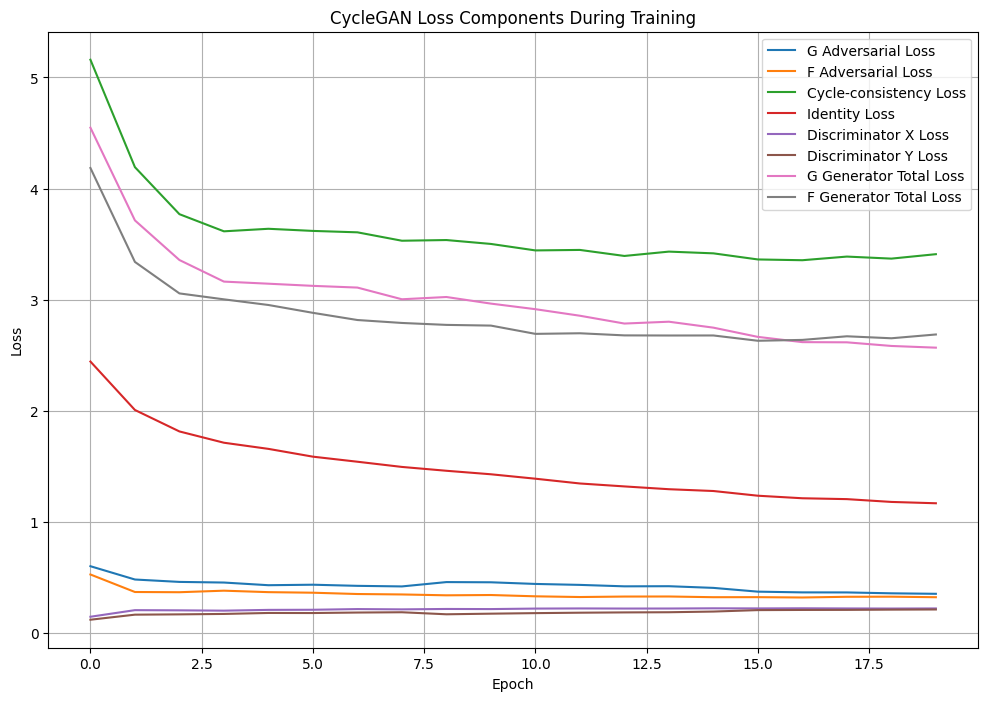

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.plot(history.history["g_adv_loss"], label="G Adversarial Loss")
plt.plot(history.history["f_adv_loss"], label="F Adversarial Loss")

plt.plot(history.history["cycle_loss"], label="Cycle-consistency Loss")
plt.plot(history.history["identity_loss"], label="Identity Loss")

plt.plot(history.history["d_x_loss"], label="Discriminator X Loss")
plt.plot(history.history["d_y_loss"], label="Discriminator Y Loss")

plt.plot(history.history["g_total_loss"], label="G Generator Total Loss")
plt.plot(history.history["f_total_loss"], label="F Generator Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CycleGAN Loss Components During Training")
plt.legend()
plt.grid(True)

plt.show()